# ShowTime OTT: Predicting First-Day Content Viewership

### Business Context:
Over-the-top (OTT) platforms deliver media content directly to users over the internet without requiring traditional cable or satellite services. These platforms provide on-demand access to movies, TV shows, and original content through websites, mobile applications, and smart TVs.

With increasing internet penetration and changing consumer preferences, OTT platforms have experienced rapid growth worldwide. Viewers are increasingly shifting from traditional broadcasting services to on-demand streaming platforms due to their flexibility, convenience, and wide content availability.To remain competitive in this fast-growing market, OTT platforms must understand the factors that influence content engagement and viewer behavior.

 
### Problem Definition:
ShowTime is an OTT streaming platform that releases various types of content such as movies and web series. The company wants to identify the key factors that influence first-day viewership of content on its platform.
Understanding these drivers will help the company optimize its content release strategy, marketing campaigns, and scheduling decisions to improve audience engagement.

The analysis aims to answer the following questions:

* Which variables are the most important predictors of first-day content viewership?
* What does the distribution of first-day content views look like?
* How is content distributed across different genres?
* How does viewership vary by day of release?
* How does seasonality affect content viewership?
* What is the relationship between trailer views and content views?


### Data Background:
The dataset contains information about various factors that may influence first-day content viewership on the ShowTime platform.
Each observation represents a content release along with several attributes describing its promotion, timing, and audience engagement.

The dataset contains the following variables:

* visitors: Average number of visitors (in millions) to the platform in the past week

* ad_impressions: Number of ad impressions (in millions) across marketing campaigns

* major_sports_event: Indicates whether a major sports event occurred on the release day

* genre: Genre of the content

* dayofweek: Day on which the content was released

* season: Season of the content release

* views_trailer: Number of trailer views (in millions)

* views_content: Number of first-day content views (in millions)

The goal of this analysis is to use these variables to build a linear regression model that identifies the key drivers of first-day content viewership.

### Importing necessary Libraries and Data:

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
# To split the data into train and test sets
from sklearn.model_selection import train_test_split

# To check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# To build linear regression model using statsmodels
import statsmodels.api as sm

# To compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# To suppress warnings
import warnings
warnings.filterwarnings("ignore")

### Loading the Data:

In [2]:
showtime_df = pd.read_csv("data/ottdata.csv")

### Data Overview: 

In [3]:
showtime_df.shape

(1000, 8)

In [4]:
showtime_df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


In [5]:
showtime_df.tail()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
995,1.58,1311.96,0,Romance,Friday,Fall,48.58,0.36
996,1.34,1329.48,0,Action,Friday,Summer,72.42,0.56
997,1.62,1359.80,1,Sci-Fi,Wednesday,Fall,150.44,0.66
998,2.06,1698.35,0,Romance,Monday,Summer,48.72,0.47
999,1.36,1140.23,0,Comedy,Saturday,Summer,52.94,0.49


In [6]:
showtime_df.sample(10)

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
179,1.58,1231.30,1,Others,Wednesday,Winter,50.09,0.54
152,1.68,1284.86,1,Horror,Friday,Spring,95.67,0.45
562,1.81,1698.35,1,Drama,Thursday,Summer,51.11,0.47
811,1.33,1216.54,0,Horror,Wednesday,Summer,54.19,0.44
521,1.70,1420.88,1,Comedy,Thursday,Summer,43.87,0.42
280,1.85,1284.86,0,Comedy,Saturday,Summer,53.70,0.53
15,1.61,1700.04,1,Horror,Monday,Fall,52.24,0.32
168,1.84,1323.74,0,Romance,Saturday,Spring,52.32,0.47
278,1.93,1623.67,0,Romance,Wednesday,Summer,46.28,0.52
590,1.78,1700.04,0,Others,Wednesday,Fall,154.39,0.71


In [7]:
#Checking the data types of the columns for the dataset:
showtime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


#### Observations:

* The dataset contains 1000 rows and 8 columns representing various factors influencing first-day content viewership.

* The columns visitors, ad_impressions, views_trailer, and views_content are numerical variables representing platform traffic, marketing reach, trailer popularity, and actual content viewership respectively.

* The column major_sports_event is a binary categorical variable (0 or 1) indicating whether a major sports event occurred on the same day as the content release.

* The columns genre, dayofweek, and season are categorical variables that describe the type of content and the timing of the release. These variables could require encoding before building the regression model.

* The target variable for the predictive model is views_content, which represents the first-day viewership (in millions).

* There are no missing values in the dataset, which simplifies the preprocessing stage since no imputation is required.

* Since the dataset contains both numerical and categorical variables, we will need to perform EDA separately for numerical distributions and categorical frequencies before building the regression model.


### Data Preprocessing:

### Checking Datatypes:

In [8]:
showtime_df.dtypes

visitors              float64
ad_impressions        float64
major_sports_event      int64
genre                  object
dayofweek              object
season                 object
views_trailer         float64
views_content         float64
dtype: object

#### Observations:
* visitors, ad_impressions, views_trailer, and views_content are numerical variables stored as float64.

* major_sports_event is an integer variable representing a binary indicator (0 or 1).

* genre, dayofweek, and season are categorical variables stored as object type.

* The categorical variables will need to be converted to dummy variables before building the regression model.

### Unique & Duplicate Values 

In [9]:
# Checking number of unique values in each column
unique_counts = showtime_df.nunique()
unique_counts


visitors               56
ad_impressions         80
major_sports_event      2
genre                   8
dayofweek               7
season                  4
views_trailer         799
views_content          61
dtype: int64

In [10]:
# checking for duplicate values
showtime_df.duplicated().sum()

0

#### Observations:

* No duplicate rows were found in the dataset.
* Therefore, no rows are needed to be removed.

### Checking for Missing Values: 

In [11]:
showtime_df.isnull().sum()

visitors              0
ad_impressions        0
major_sports_event    0
genre                 0
dayofweek             0
season                0
views_trailer         0
views_content         0
dtype: int64

#### Observations:
* There are no missing values in any of the columns of the ShowTime dataset.

* All 8 variables have complete data, so no missing value treatment or imputation is required.

### Inspecting categorical variables: 

In [12]:
# Checking the unique values and counts of categorical variables
categorical_cols = ["major_sports_event", "genre", "dayofweek", "season"]

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(showtime_df[col].value_counts())


Column: major_sports_event
0    600
1    400
Name: major_sports_event, dtype: int64

Column: genre
Others      255
Comedy      114
Thriller    113
Drama       109
Romance     105
Sci-Fi      102
Horror      101
Action      101
Name: genre, dtype: int64

Column: dayofweek
Friday       369
Wednesday    332
Thursday      97
Saturday      88
Sunday        67
Monday        24
Tuesday       23
Name: dayofweek, dtype: int64

Column: season
Winter    257
Fall      252
Spring    247
Summer    244
Name: season, dtype: int64


#### Observations:

* The variable major_sports_event shows that 600 releases occurred without a major sports event, while 400 releases coincided with a sports event.

* The genre distribution is fairly spread across categories, with Others being the most common, followed by Comedy, Thriller, and Drama.

* The dayofweek distribution shows that most content is released on Friday and Wednesday, suggesting these are the preferred release days.

* Very few releases occur on Monday and Tuesday, indicating these days are rarely chosen for content launches.

* The season distribution is almost evenly balanced across Winter, Fall, Spring, and Summer, meaning the dataset does not have seasonal imbalance.

### Standardizing Categorical Text Columns: 

In [13]:
# standardizing categorical text columns
text_cols = ["genre", "dayofweek", "season"]

for col in text_cols:
    showtime_df[col] = showtime_df[col].str.strip().str.lower()

In [14]:
#Verifying the changes
for col in text_cols:
    print(f"\nColumn: {col}")
    print(showtime_df[col].unique())


Column: genre
['horror' 'thriller' 'sci-fi' 'others' 'drama' 'action' 'comedy' 'romance']

Column: dayofweek
['wednesday' 'friday' 'sunday' 'thursday' 'monday' 'saturday' 'tuesday']

Column: season
['spring' 'fall' 'winter' 'summer']


* The categorical variables genre, dayofweek, and season were standardized by removing extra spaces and converting text to lowercase.

* This ensures consistency in category labels and prevents duplicate categories caused by formatting differences.

* The cleaned categorical variables are now ready for EDA and encoding during model building.

### Converting the binary variable into a meaningful label:

In [15]:
# converting binary variable into meaningful labels
showtime_df["major_sports_event"] = showtime_df["major_sports_event"].map({0: "No", 1: "Yes"})

In [16]:
#verifying
showtime_df["major_sports_event"].value_counts()

No     600
Yes    400
Name: major_sports_event, dtype: int64

#### Observations:
* The variable major_sports_event originally contained binary values 0 and 1.

* These values were converted into "No" and "Yes" labels to improve interpretability during exploratory data analysis and visualization.

* This transformation does not change the underlying information but makes the dataset easier to understand.

### Checking for invalid numeric values:

In [17]:
# checking for non-positive values
numeric_cols = ["visitors", "ad_impressions", "views_trailer", "views_content"]

for col in numeric_cols:
    print(col, ":", (showtime_df[col] <= 0).sum(), "non-positive values")

visitors : 0 non-positive values
ad_impressions : 0 non-positive values
views_trailer : 0 non-positive values
views_content : 0 non-positive values


In [18]:
# checking summary statistics for numeric variables
showtime_df[["visitors", "ad_impressions", "views_trailer", "views_content"]].describe().T

,count,mean,std,min,25%,50%,75%,max
visitors,1000.0,1.70429,0.231973,1.25,1.5500,1.70,1.830,2.34
ad_impressions,1000.0,1434.71229,289.534834,1010.87,1210.3300,1383.58,1623.670,2424.20
views_trailer,1000.0,66.91559,35.001080,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,0.47340,0.105914,0.22,0.4000,0.45,0.520,0.89


#### Observations:
* The numerical variables were checked using summary statistics.

* The average platform visitors is about 1.7 million, and ad impressions average around 1434 million.

* The average trailer views are about 66.9 million, with some trailers receiving significantly higher views.

* The average first-day content viewership is approximately 0.47 million.

* No invalid or non-positive values were found in the numerical variables.

### Feature Engineering: 

* The dataset already contains meaningful predictor variables such as visitors, ad impressions, trailer views, genre, season, and day of release.

* Since most content releases occur on Fridays and Wednesdays, creating additional timing features (such as weekend indicators) would not add significant value.

* Therefore, no additional feature engineering was performed, and the existing variables are used directly for modeling 

### Exploratory Data Analysis: 

### Statistical Summary of the Dataset:

In [19]:
showtime_df.describe().T

,count,mean,std,min,25%,50%,75%,max
visitors,1000.0,1.70429,0.231973,1.25,1.5500,1.70,1.830,2.34
ad_impressions,1000.0,1434.71229,289.534834,1010.87,1210.3300,1383.58,1623.670,2424.20
views_trailer,1000.0,66.91559,35.001080,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,0.47340,0.105914,0.22,0.4000,0.45,0.520,0.89


### Univariate Analysis:
    

### Distribution of First-Day Content Views (Target Variable):

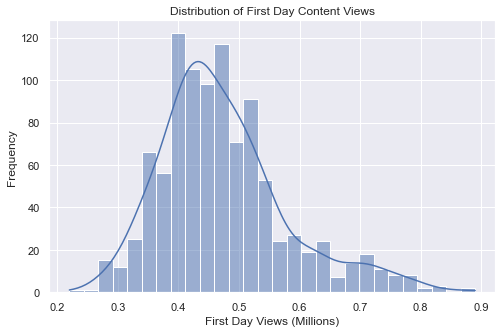

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(showtime_df["views_content"], kde=True)
plt.title("Distribution of First Day Content Views")
plt.xlabel("First Day Views (Millions)")
plt.ylabel("Frequency")
plt.show()

#### Observations:
* The distribution of first-day content views appears slightly right-skewed.
* Most content receives between 0.4 and 0.5 million views on the first day.

### Boxplot of First-Day Content Views (Outlier Check):

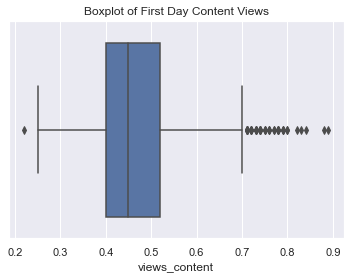

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x=showtime_df["views_content"])
plt.title("Boxplot of First Day Content Views")
plt.show()

#### Observation:
* The boxplot shows a few higher-value outliers, indicating that some content achieves significantly higher viewership than the majority.

### Distribution of Trailer Views:

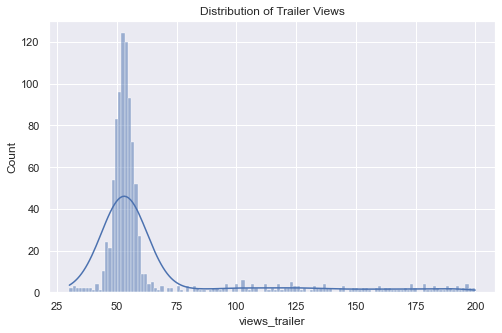

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(showtime_df["views_trailer"], kde=True)
plt.title("Distribution of Trailer Views")
plt.show()

#### Observations:
* The distribution of trailer views is heavily right-skewed.
* Most trailers receive between 45 and 60 million views, while a small number achieve extremely high viewership.
* These higher values likely correspond to highly anticipated or heavily marketed content releases.

### Distribution of Platform Visitors:

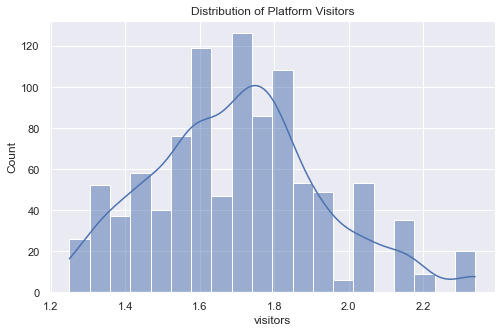

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(showtime_df["visitors"], kde=True)
plt.title("Distribution of Platform Visitors")
plt.show()

#### Observations:
* The distribution of platform visitors is approximately normal.

* Most weeks record between 1.5 and 1.9 million visitors, indicating relatively stable platform traffic.

### Distribution of Ad Impressions:

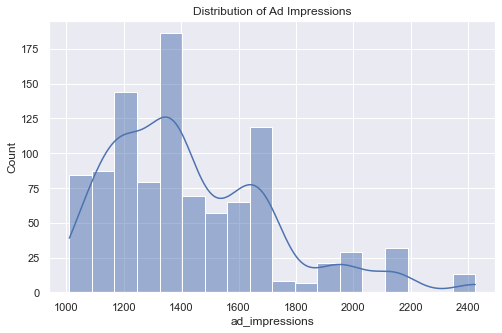

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(showtime_df["ad_impressions"], kde=True)
plt.title("Distribution of Ad Impressions")
plt.show()

#### Observations:
* The distribution of ad impressions is moderately right-skewed.

* Most content receives between 1200 and 1700 million ad impressions, while a few campaigns have significantly higher marketing exposure.

### Distribution of Genres:

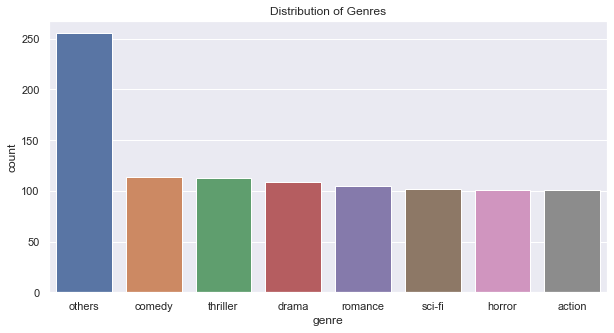

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data=showtime_df, x="genre",
              order=showtime_df["genre"].value_counts().index)
plt.title("Distribution of Genres")
plt.show()

### Distribution of Release Day:

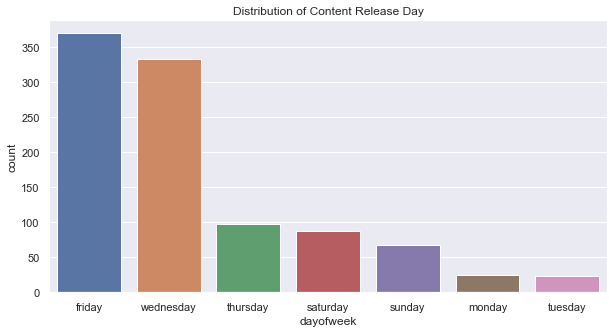

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(data=showtime_df, x="dayofweek",
              order=showtime_df["dayofweek"].value_counts().index)
plt.title("Distribution of Content Release Day")
plt.show()

### Distribution of Season:

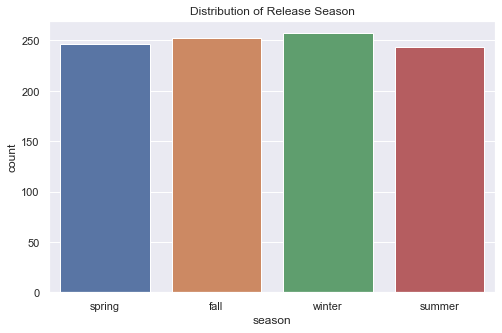

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(data=showtime_df, x="season")
plt.title("Distribution of Release Season")
plt.show()

### Distribution of Sports Events:

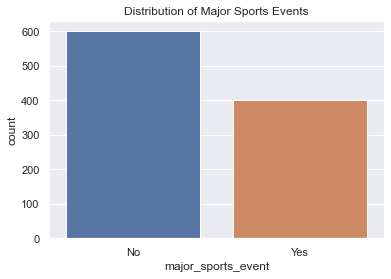

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=showtime_df, x="major_sports_event")
plt.title("Distribution of Major Sports Events")
plt.show()

#### Observations on Categorical Columns:
* The “Others” category dominates the dataset.
* Other genres such as Comedy, Thriller, Drama, Romance, Sci-Fi, Horror, and Action appear relatively balanced.
* This suggests the platform hosts a diverse mix of content types.
* The majority of content releases occur on Friday and Wednesday.
* Very few releases occur on Monday and Tuesday.
* This indicates that platforms strategically release content closer to the weekend period.
* Content releases are fairly evenly distributed across all four seasons.
* No strong seasonal bias is observed in the dataset.
* Most content releases (around 60%) occur without a major sports event.
* About 40% of releases coincide with major sports events, which could potentially impact viewership.

### Bivariate Analysis:

### Trailer Views vs Content Views:

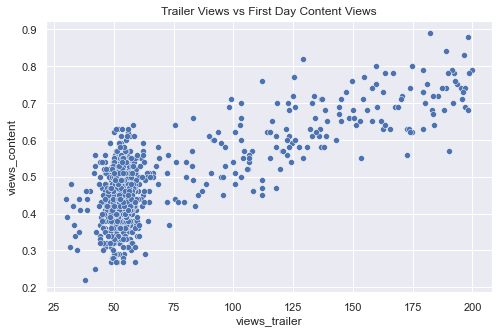

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=showtime_df,
    x="views_trailer",
    y="views_content"
)
plt.title("Trailer Views vs First Day Content Views")
plt.show()

#### Observations:
* There is a strong positive relationship between trailer views and first-day content views.
* Content with higher trailer engagement generally receives higher first-day viewership.

### Platform Visitors vs Content Views:

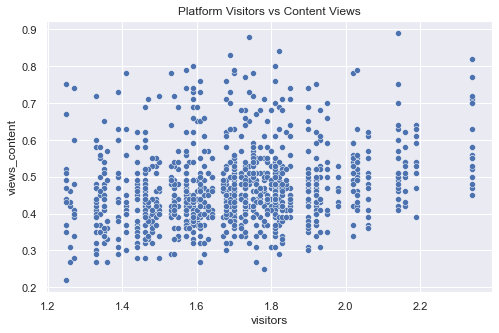

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=showtime_df,
    x="visitors",
    y="views_content"
)
plt.title("Platform Visitors vs Content Views")
plt.show()

#### Observations:
* A weak positive relationship is observed between platform visitors and first-day content views.
* Higher platform traffic may contribute to increased content viewership, but the relationship is not very strong.

### Ad Impressions vs Content Views:

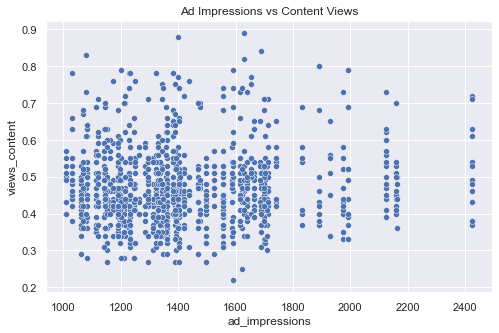

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=showtime_df,
    x="ad_impressions",
    y="views_content"
)
plt.title("Ad Impressions vs Content Views")
plt.show()

#### Observations:
* The scatter plot shows no clear linear relationship between ad impressions and first-day content views.
* This indicates that ad impressions alone may not strongly drive immediate viewership.

### Content Views by Genre:

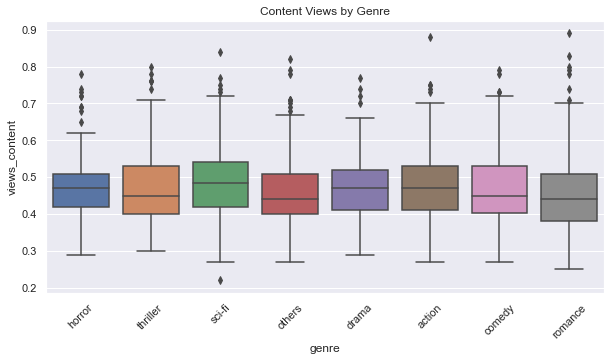

In [32]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=showtime_df,
    x="genre",
    y="views_content"
)
plt.title("Content Views by Genre")
plt.xticks(rotation=45)
plt.show()

#### Observations:
* Viewership varies slightly across genres, but the median viewership is relatively similar across most categories.
* Some genres such as Sci-Fi, Action, and Drama show slightly higher upper ranges of viewership.
* Overall, genre does not appear to be a dominant factor influencing first-day views.

### Content Views by Release Day:

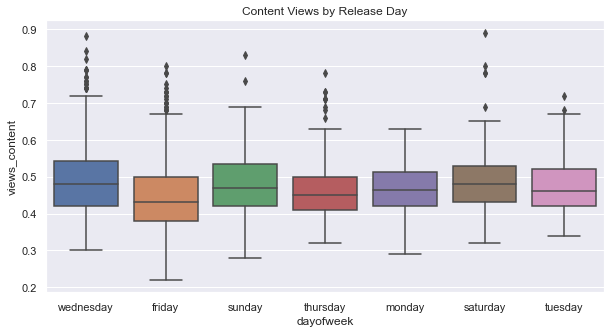

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=showtime_df,
    x="dayofweek",
    y="views_content"
)
plt.title("Content Views by Release Day")
plt.show()

#### Observations:
* Viewership patterns differ slightly across release days.
* Wednesday, Saturday, and Sunday releases appear to show slightly higher median viewership compared to other days.
* This suggests that release timing may influence audience engagement.

### Content Views by Season:

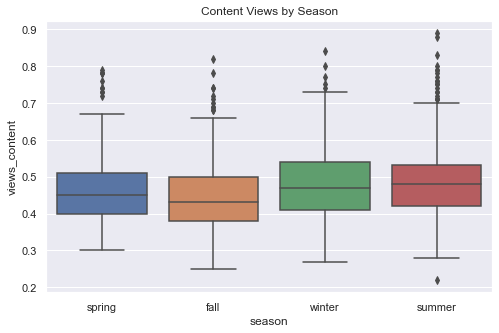

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=showtime_df,
    x="season",
    y="views_content"
)
plt.title("Content Views by Season")
plt.show()

#### Observations:
* Seasonal variation in viewership is present but not extremely pronounced.
* Winter and Summer releases appear to show slightly higher median viewership compared to Spring and Fall.

### Content Views vs Sports Events:

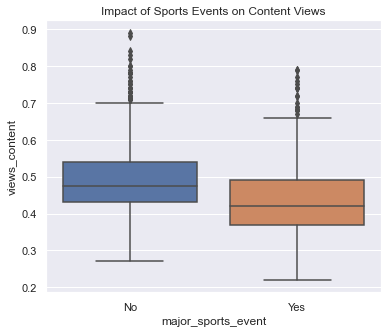

In [35]:
plt.figure(figsize=(6,5))
sns.boxplot(
    data=showtime_df,
    x="major_sports_event",
    y="views_content"
)
plt.title("Impact of Sports Events on Content Views")
plt.show()

#### Observations:
* Content released on days without major sports events tends to have slightly higher median viewership.
* When major sports events occur, viewership appears to decline slightly, possibly due to audience attention shifting to live sports.

### Correlation Heatmap:

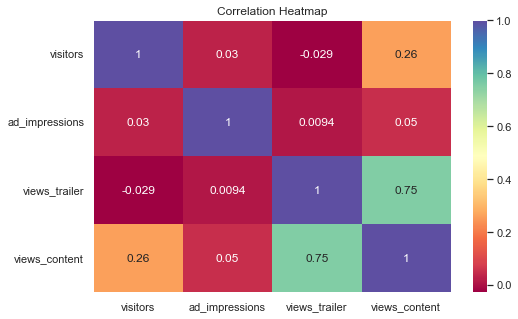

In [36]:
plt.figure(figsize=(8,5))
numeric_df = showtime_df.select_dtypes(include=['number'])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Spectral"
)
plt.title("Correlation Heatmap")
plt.show()

#### Observations:
* Trailer views have the strongest positive correlation with content views (0.75).
* Platform visitors show a moderate positive correlation (0.26) with content views.
* Ad impressions show almost no correlation (~0.05) with first-day content views.
* Trailer popularity therefore appears to be the most important predictor of first-day viewership.

### Boxplot for all numeric variables: 

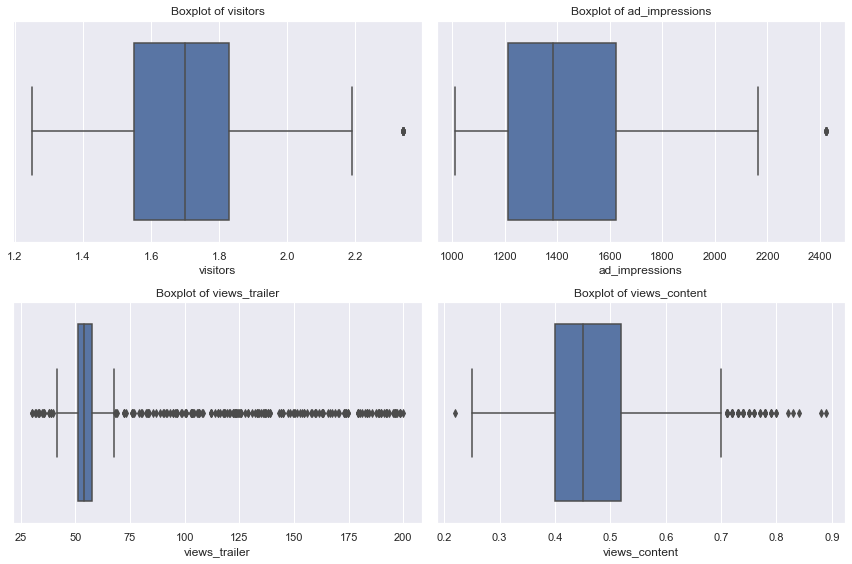

In [37]:
numeric_cols = ["visitors", "ad_impressions", "views_trailer", "views_content"]

plt.figure(figsize=(12,8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=showtime_df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

#### Observations:

#### Visitors:
* The distribution of platform visitors appears relatively symmetric with most values concentrated between 1.5 and 1.8 million.
* There are very few outliers, indicating that platform traffic is generally stable.
#### Ad Impressions:
* The ad impressions variable shows a moderate spread with most values lying roughly between 1200 and 1600 million impressions.
* A few higher-value outliers are observed, indicating that some content received significantly higher marketing exposure.
#### Trailer Views:
* The distribution of trailer views is highly right-skewed with a large number of high-value outliers.
* Most trailers receive views around 50–60 million, while some trailers receive extremely high views (up to ~200 million).
* These extreme values likely correspond to highly promoted or very popular content trailers.
#### Content Views:
* First-day content views are moderately spread around 0.4–0.5 million views.
* Some higher-value outliers are present, indicating that certain titles significantly outperform the average content.
* These outliers are expected in entertainment platforms where a few releases become very popular compared to the majority.

#### Conclusion:
The boxplots show some extreme values, particularly in trailer views and first-day content views. However, these values likely represent highly popular or heavily marketed content rather than data entry errors as there are no negative values, impossible numbers or unrealistic orders of magnitude. Since the values fall within plausible ranges for digital media platforms, no outlier removal is performed at this stage.

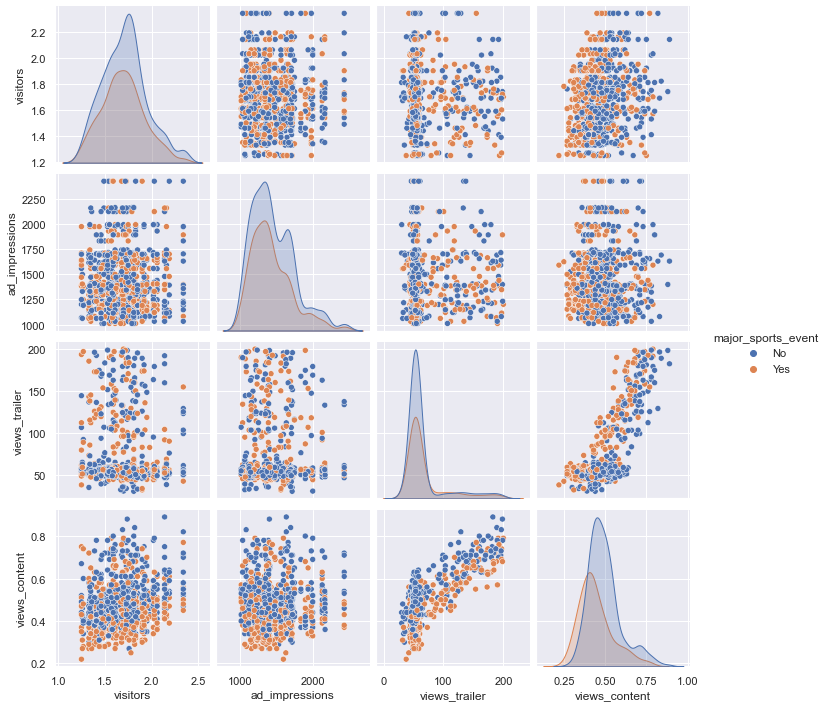

In [38]:
# Pairplot analysis:
sns.pairplot(
    showtime_df,
    vars=["visitors", "ad_impressions", "views_trailer", "views_content"],
    hue="major_sports_event"
)

plt.show()

### Observations:
* The pairplot provides a visual summary of relationships among numerical variables.
* Trailer views show a strong positive relationship with content views, confirming earlier findings.
* Platform visitors show a moderate relationship with content views.
* Ad impressions do not appear to have a strong direct relationship with first-day content views.

### Answers to Key EDA Questions:

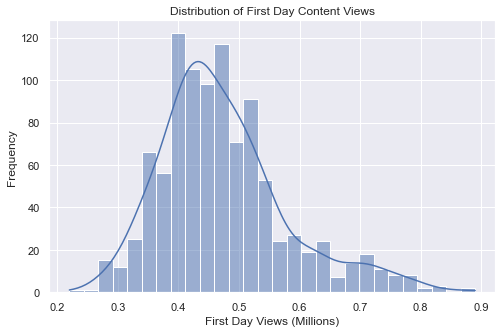

In [39]:
# 1) What does the distribution of content views look like?

plt.figure(figsize=(8,5))
sns.histplot(showtime_df["views_content"], kde=True)
plt.title("Distribution of First Day Content Views")
plt.xlabel("First Day Views (Millions)")
plt.ylabel("Frequency")
plt.show()

* The distribution of first-day content views is slightly right-skewed, with most content receiving between 0.4 and 0.5 million views. A few titles achieve significantly higher viewership, which appear as outliers in the boxplot, indicating that some content performs exceptionally well compared to the majority. 

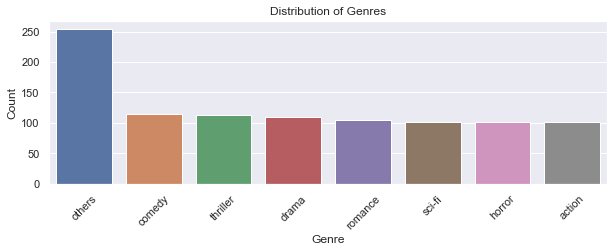

In [40]:
# 2) What does the distribution of genres look like?

plt.figure(figsize=(10,3))
sns.countplot(
    data=showtime_df,
    x="genre",
    order=showtime_df["genre"].value_counts().index
)
plt.title("Distribution of Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

* The dataset contains a variety of genres, with the “Others” category having the highest count of content releases. The remaining genres such as Comedy, Thriller, Drama, Romance, Sci-Fi, Horror, and Action are relatively balanced in distribution, suggesting that the platform offers a diverse mix of content types.

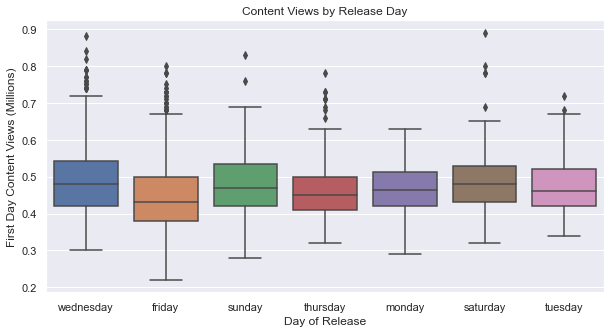

In [41]:
# 3) How does the viewership vary with the day of release?

plt.figure(figsize=(10,5))
sns.boxplot(
    data=showtime_df,
    x="dayofweek",
    y="views_content"
)
plt.title("Content Views by Release Day")
plt.xlabel("Day of Release")
plt.ylabel("First Day Content Views (Millions)")
plt.show()

* Viewership varies slightly depending on the release day. Wednesday, Saturday, and Sunday releases tend to show slightly higher median viewership, while Friday releases appear slightly lower in comparison. However, the differences are not extremely large, indicating that while release timing may influence viewership, it is not the dominant factor.

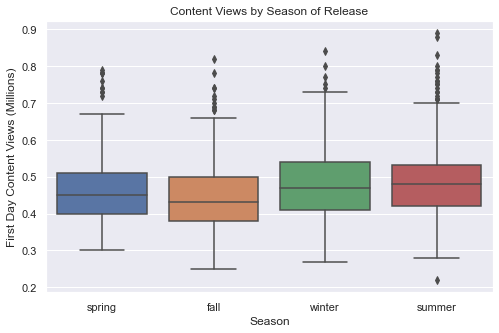

In [42]:
# 4) How does the viewership vary with the season of release?

plt.figure(figsize=(8,5))
sns.boxplot(
    data=showtime_df,
    x="season",
    y="views_content"
)
plt.title("Content Views by Season of Release")
plt.xlabel("Season")
plt.ylabel("First Day Content Views (Millions)")
plt.show()

* Seasonal variation in viewership is present but not very pronounced. Winter and Summer releases show slightly higher median viewership, while Spring and Fall releases show marginally lower values. Overall, seasonality appears to have a moderate but not strong influence on first-day viewership.

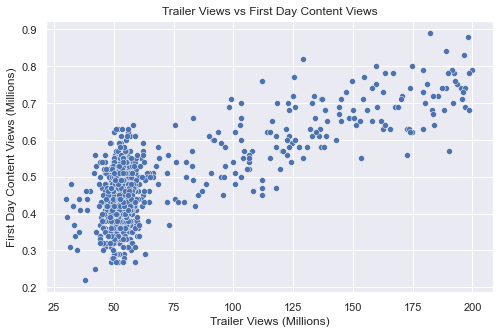

In [43]:
# 5) What is the correlation between trailer views and content views?

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=showtime_df,
    x="views_trailer",
    y="views_content"
)
plt.title("Trailer Views vs First Day Content Views")
plt.xlabel("Trailer Views (Millions)")
plt.ylabel("First Day Content Views (Millions)")
plt.show()

In [44]:
showtime_df[["views_trailer", "views_content"]].corr()

,views_trailer,views_content
views_trailer,1.000000,0.753962
views_content,0.753962,1.000000


* There is a strong positive correlation (≈ 0.75) between trailer views and first-day content views. The scatter plot clearly shows that content with higher trailer engagement tends to receive higher first-day viewership. This suggests that trailer popularity is one of the strongest drivers of content performance on the platform.

### Model Building - Linear Regression

* The objective of this analysis is to predict first-day content viewership (views_content) using the available predictor variables in the dataset.

* Since the dataset contains categorical variables such as genre, dayofweek, season, and major_sports_event, these need to be converted into dummy variables before fitting the regression model.

* To evaluate the model properly, the data will be split into train and test sets. A Linear Regression model will then be fitted on the training data, and its performance will be evaluated on both training and testing datasets.

In [45]:
# defining dependent and independent variables
X = showtime_df.drop("views_content", axis=1)
y = showtime_df["views_content"]

In [46]:
# creating dummy variables for categorical features
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True,
)
X = X.astype(float)
X.head()

,visitors,ad_impressions,views_trailer,major_sports_event_Yes,genre_comedy,genre_drama,genre_horror,genre_others,genre_romance,genre_sci-fi,genre_thriller,dayofweek_monday,dayofweek_saturday,dayofweek_sunday,dayofweek_thursday,dayofweek_tuesday,dayofweek_wednesday,season_spring,season_summer,season_winter
0,1.67,1113.81,56.70,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.46,1498.41,52.69,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.47,1079.19,48.74,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.85,1342.77,49.81,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.46,1498.41,55.83,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [47]:
# splitting the data into train and test sets in 70:30 ratio
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 700
Number of rows in test data = 300


In [48]:
# adding a constant for statsmodels
x_train = sm.add_constant(x_train)
x_test = sm.add_constant(x_test)

In [49]:
# fitting the linear regression model
olsmodel1 = sm.OLS(y_train, x_train).fit()

print(olsmodel1.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Sun, 08 Mar 2026   Prob (F-statistic):          1.32e-215
Time:                        23:38:07   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

#### Observations:
#### Overall Model Fit:

* The model has an R-squared value of 0.792, which indicates that approximately 79.2% of the variation in first-day content viewership is explained by the predictor variables.

* The Adjusted R-squared value is 0.785, which is very close to the R-squared value. This suggests that the model is not overfitting and most variables contribute meaningfully to the model.

* The F-statistic is highly significant (p-value ~ 0), indicating that the overall regression model is statistically significant.



In [50]:
# displaying model coefficients with column names
coef_df = pd.DataFrame({
    "Feature": olsmodel1.params.index,
    "Coefficient": olsmodel1.params.values
})

coef_df

,Feature,Coefficient
0,const,0.060157
1,visitors,0.129451
2,ad_impressions,0.000004
3,views_trailer,0.002330
4,major_sports_event_Yes,-0.060326
5,genre_comedy,0.009352
6,genre_drama,0.012625
7,genre_horror,0.009862
8,genre_others,0.006325
9,genre_romance,0.000551


#### Key Significant Predictors:
1] Visitors

* The coefficient for visitors (0.129) is positive and highly significant.

* This indicates that higher platform traffic in the past week strongly increases first-day content viewership.

* This variable appears to be one of the most important drivers of content performance.


2] Major Sports Events

* The coefficient for major_sports_event_Yes (-0.060) is negative and statistically significant.

* This indicates that major sports events reduce first-day content viewership, likely because viewers shift their attention to live sports events.

3] Effect of Release Day

* Several release days significantly impact viewership:

* Saturday (0.058) and Wednesday (0.047) show strong positive effects on viewership.

* Sunday (0.036) and Monday (0.033) also show positive impacts.

* This suggests that content released closer to weekends tends to attract more viewers.

4] Effect of Season

* Seasonal effects are also significant

* Summer (0.044) has the strongest positive impact on viewership.

* Winter (0.027) and Spring (0.023) also increase viewership compared to the reference season.

* This suggests that seasonal viewing behavior influences content consumption on the platform.

5] Genre Effects

* Most genre variables are not statistically significant, indicating that genre alone may not strongly determine first-day viewership.

* This suggests that platform traffic, marketing engagement, and release timing are more influential factors.


Conclusion:
* The condition number is relatively large, which may indicate possible multicollinearity among some predictors. However, further diagnostics such as Variance Inflation Factor (VIF) should be conducted to confirm this.

* The model suggests that platform traffic, trailer engagement, release timing, and external events (such as sports events) are the strongest drivers of first-day content viewership.

### Checking Linear Regression Assumptions:

### Test For Multicollineatity: 

In [51]:
# function to check VIF
def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

In [52]:
# checking VIF on the training data
checking_vif(x_train)

,feature,VIF
0,const,99.679317
1,visitors,1.027837
2,ad_impressions,1.029390
3,views_trailer,1.023551
4,major_sports_event_Yes,1.065689
5,genre_comedy,1.917635
6,genre_drama,1.926699
7,genre_horror,1.904460
8,genre_others,2.573779
9,genre_romance,1.753525


#### Observations:

* The VIF values for all predictor variables are well below 5, indicating that multicollinearity is not a concern in this model.

* The numerical variables visitors, ad_impressions, and views_trailer have VIF values very close to 1, which suggests they are highly independent of one another.

* The categorical dummy variables also have acceptable VIF values, mostly between 1 and 2.6.

* The high VIF for const can be ignored, as it is the intercept term and not interpreted like the predictor variables.

#### Conclusion:

The assumption of no multicollinearity is satisfied.

Since there is no significant multicollinearity, we do not need to remove any variables at this stage.

### Test Linearity and Independence of Errors:

In [53]:
# creating a dataframe with actual, fitted, and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train
df_pred["Fitted Values"] = olsmodel1.fittedvalues
df_pred["Residuals"] = olsmodel1.resid

df_pred.head()

,Actual Values,Fitted Values,Residuals
731,0.40,0.452102,-0.052102
716,0.70,0.679675,0.020325
640,0.42,0.431537,-0.011537
804,0.55,0.562329,-0.012329
737,0.59,0.552069,0.037931


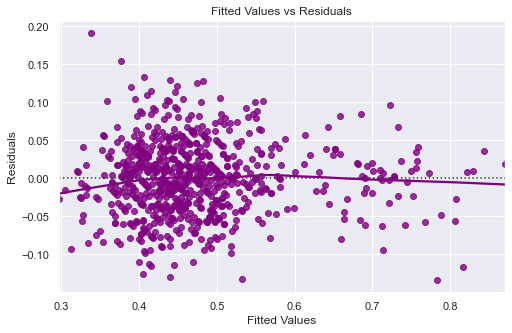

In [54]:
# plotting fitted values vs residuals
plt.figure(figsize=(8,5))
sns.residplot(
    data=df_pred,
    x="Fitted Values",
    y="Residuals",
    lowess=True,
    color="purple"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted Values vs Residuals")
plt.show()

#### Observations:

* The Residuals vs Fitted Values plot shows that the residuals are randomly scattered around zero.

* There is no clear systematic pattern (such as a curve, funnel, or clustering) in the residual distribution.

* The spread of residuals appears fairly symmetric around the horizontal line at zero, which indicates that the model captures the underlying linear relationship reasonably well.

* Since the residuals do not show any obvious structure or dependency pattern, the independence of error terms assumption is also satisfied.

#### Conclusion:

* The assumptions of linearity between predictors and the target variable and independence of residuals appear to be satisfied for this regression model. 

### Test for Normality of Residuals: 

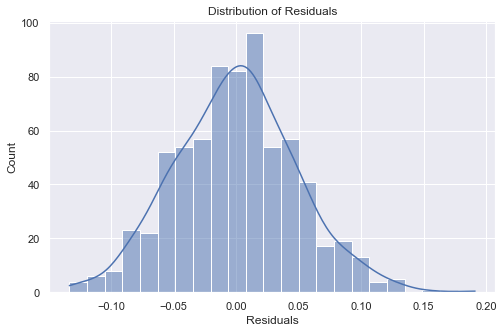

In [55]:
#Histogram of Residuals:
plt.figure(figsize=(8,5))
sns.histplot(df_pred["Residuals"], kde=True)
plt.title("Distribution of Residuals")
plt.show()

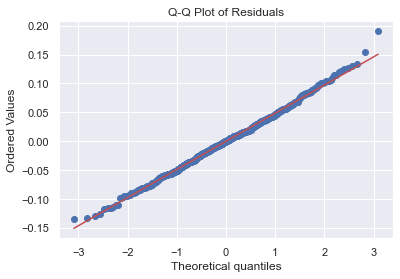

In [56]:
# Q-Q Plot:
import scipy.stats as stats
import pylab

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [57]:
# Shapiro-Wilk Test
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=0.9972290992736816, pvalue=0.28409022092819214)

#### Observations:

* The histogram of residuals shows a bell-shaped distribution, suggesting that the residuals are approximately normally distributed.

* The Q-Q plot indicates that most of the residual points lie very close to the reference straight line, which further supports the assumption of normality.

* The Shapiro–Wilk test gives a p-value = 0.284, which is greater than 0.05.

#### Conclusion:

* Since the p-value > 0.05, we fail to reject the null hypothesis that the residuals are normally distributed.

* Therefore, the normality assumption of linear regression is satisfied. 

### Test for Homoscedasticity (Constant Variance of Errors): 

In [58]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train)
lzip(name, test)

[('F statistic', 1.1444079593563592), ('p-value', 0.1108677095752728)]

#### Observations:
* F-statistic = 1.144
* p-value = 0.1109
* Since the p-value > 0.05, we fail to reject the null hypothesis.

#### Conclusion:

* Because the p-value is greater than 0.05, there is no statistical evidence of heteroscedasticity.

* Therefore, the homoscedasticity assumption of linear regression is satisfied.

### Model Performance Evaluation:

* The objective of this analysis is to predict first-day content viewership (views_content) using the available predictor variables in the dataset.

* Since the dataset contains categorical variables such as genre, dayofweek, season, and major_sports_event, these need to be converted into dummy variables before fitting the regression model.

* To evaluate the model properly, the data will be split into train and test sets. A Linear Regression model will then be fitted on the training data, and its performance will be evaluated on both training and testing datasets.

In [59]:
# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100

In [60]:
# function to compute regression model performance
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: fitted regression model
    predictors: independent variables
    target: dependent variable
    """
    pred = model.predict(predictors)

    rmse = np.sqrt(mean_squared_error(target, pred))
    mae = mean_absolute_error(target, pred)
    mape = mape_score(target, pred)
    r2 = r2_score(target, pred)

    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape,
            "R-squared": r2,
        },
        index=[0],
    )

    return df_perf

In [61]:
# checking model performance on train set
print("Training Performance:")
olsmodel1_perf_train = model_performance_regression(olsmodel1, x_train, y_train)
olsmodel1_perf_train

Training Performance:


,RMSE,MAE,MAPE,R-squared
0,0.04853,0.038197,8.55644,0.791616


#### Observations:
* The model achieved an RMSE of 0.0485 on the training data, indicating that the model's predictions deviate from the actual values by approximately 0.048 million views on average.

* The MAE is 0.038, suggesting that the model's average absolute prediction error is relatively small.

* The MAPE is approximately 8.56%, meaning the model can predict first-day viewership with an average error of about 8–9% on the training data.

* The R-squared value of 0.792 indicates that the model explains about 79% of the variability in content viewership.

In [62]:
# checking model performance on test set
print("Test Performance:")
olsmodel1_perf_test = model_performance_regression(olsmodel1, x_test, y_test)
olsmodel1_perf_test

Test Performance:


,RMSE,MAE,MAPE,R-squared
0,0.050603,0.040782,9.030464,0.766447


#### Observations:
* On the test dataset, the model achieved an RMSE of 0.0506, which is only slightly higher than the training RMSE.

* The MAE on the test data is 0.0408, indicating that the model maintains good predictive accuracy on unseen data.

* The MAPE is approximately 9.03%, which suggests that the model's predictions deviate from the actual values by about 9% on average.

* The R-squared value on the test set is 0.766, which is close to the training R-squared value.

#### Model Generalization

* The performance metrics on the training and test datasets are very similar, indicating that the model generalizes well and is not significantly overfitting.

* The small difference between training and test performance suggests that the model is stable and reliable for predicting first-day content viewership.

#### Overall Model Performance

* The model demonstrates good predictive capability, explaining a large proportion of variance in the target variable.

* With a MAPE of around 9%, the model can predict first-day content views with reasonably high accuracy. 

### Actionable Insights and Business Recommendations:
####  Model Effectiveness:

The linear regression model explains a significant portion of the variation in first-day content viewership.

* Training R²: 0.79
* Test R²: 0.77

* The MAPE of approximately 9% on the test data indicates that the model can predict first-day content views with good accuracy. The training and test errors are close, suggesting that the model generalizes well and is not overfitting.

#### Significance of Predictors:
The regression results indicate that the following variables significantly influence first-day content views:

* Trailer Views:
Trailer views have the strongest positive impact on content viewership. Higher trailer engagement leads to higher first-day views, highlighting the importance of effective trailer marketing.

* Platform Visitors:
A higher number of visitors on the platform increases the likelihood of users watching newly released content, positively influencing viewership.

* Major Sports Events:
The presence of a major sports event negatively affects content views, suggesting that audiences may shift their attention to live sports instead of streaming content.

* Day of Release:
Content released on certain days, particularly Wednesdays and weekends, tends to receive higher first-day viewership.

* Season of Release:
Seasonal effects are also observed, with summer and winter releases generally attracting higher engagement.

#### Key Takeaways for the Business:

* The analysis suggests that marketing exposure, platform traffic, and release timing are the key drivers of first-day content views.

* To improve viewership, the platform should:

    * Invest in strong trailer marketing campaigns

    * Increase platform traffic through promotions and recommendations

    * Schedule releases strategically on high-engagement days

    * Avoid launching major content during large sports events

    * Plan premium releases during high engagement seasons

* These strategies can help improve first-day content performance and overall audience engagement on the platform.